# 05 Where the Bend Sits

| | |
|---|---|
| **Path** | Multilayer perceptron |
| **Prerequisite** | 04 |

The two pass gates, 10 and 01, sit on the bend $x_1 + x_2 = 1$. Gate 00 is on the side where the second hidden unit is off. Gate 11 is on the side where that unit is on and the output has folded back to $0$.

The picture uses the same colors as the earlier paths. Pass is green. Fail is clay. The blue segment is the bend.


## Example 1 — The four corners and the segment between the passes

The segment runs from $(0, 1)$ to $(1, 0)$. Its endpoints are the pass gates. That is a fact about these weights, not a decoration: $h_2 = 0$ exactly on that segment, and $h_2 > 0$ on the side that contains $(1, 1)$.


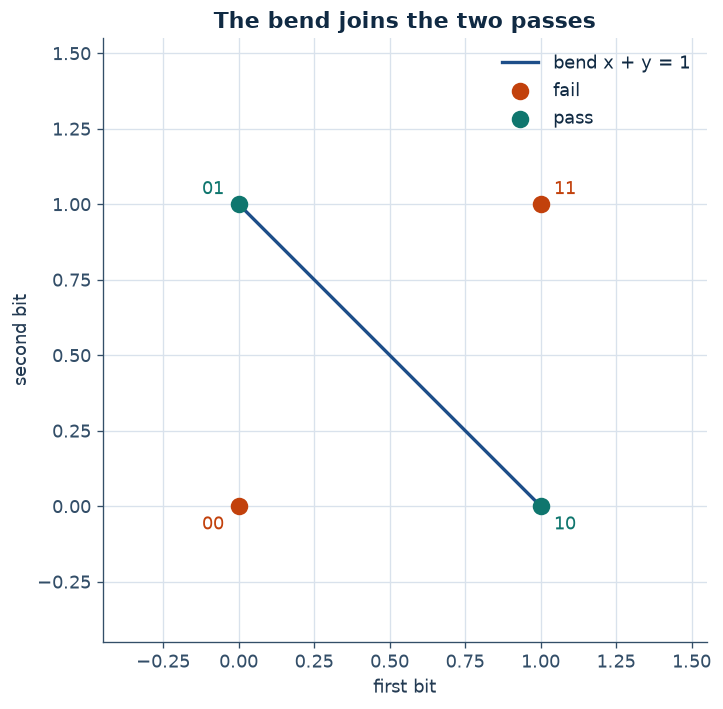

In [1]:
# The bend is the segment joining the two pass gates.
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
})
blue = "#1d4e89"
clay = "#c2410c"
green = "#0f766e"
fig, ax = plt.subplots(figsize=(6.4, 5.8), constrained_layout=True)
ax.plot([0, 1], [1, 0], color=blue, linewidth=2, label="bend x + y = 1", zorder=2)
ax.scatter([0, 1], [0, 1], s=90, color=clay, zorder=3, label="fail")
ax.scatter([1, 0], [0, 1], s=90, color=green, zorder=3, label="pass")
ax.annotate("00", (0, 0), textcoords="offset points", xytext=(-22, -14), color=clay)
ax.annotate("10", (1, 0), textcoords="offset points", xytext=(8, -14), color=green)
ax.annotate("01", (0, 1), textcoords="offset points", xytext=(-22, 6), color=green)
ax.annotate("11", (1, 1), textcoords="offset points", xytext=(8, 6), color=clay)
ax.set_xlim(-0.45, 1.55)
ax.set_ylim(-0.45, 1.55)
ax.set_aspect("equal")
ax.set_xlabel("first bit")
ax.set_ylabel("second bit")
ax.set_title("The bend joins the two passes")
ax.legend(frameon=False)


## Example 2 — Which side is on

A point is strictly above the bend when $x_1 + x_2 > 1$. Gate 11 has sum $2$. Gate 00 has sum $0$. The pass gates have sum $1$ and sit on it.


In [2]:
# Sums: fail at the origin, the two passes on the bend, fail at the far corner.
sums = [0 + 0, 1 + 0, 0 + 1, 1 + 1]
print(sums)
assert sums == [0, 1, 1, 2]


[0, 1, 1, 2]


## Pitfall — The bend is not a decision boundary drawn through the fails

The blue segment is where a hidden unit switches on. The output is already the right target on both sides of it, for these four gates. Do not read the segment as "pass on one side, fail on the other." Both fails are off the segment, on opposite sides, and the fold is what brings the far fail back to zero.


## Summary

The second hidden unit switches on along the segment from gate 01 to gate 10. Gate 00 is off that unit. Gate 11 is on it, and the output weight $-2$ folds the score back to the target.
